In [1]:
# =====================================================
# SECTION 1: LOAD PREPROCESSED DATASET
# =====================================================

import pandas as pd

df = pd.read_csv("../data/PROCESSED/NSCH_Preprocessed_ADHD.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (89228, 582)


,HEIGHT,FIPSST,STRATUM,HHID,FORMTYPE,TOTKIDS_R,TENURE,HHLANGUAGE,SC_AGE_YEARS,SC_SEX,...,npmCareCoorR_2324,nomCavities_2324,nomChHlthSt_2324,nomObesity6to17_2324,nomFlrish6to17_2324,nomACE2more_2324,smSmoking_2324,smAdeqIns_2324,smForgoneHC_2324,ADHD_binary
0,152.40,51,1,23000001,2,1,3,1.0,8,2,...,1.0,2.0,1.0,2,2.0,2.0,2.0,1.0,2.0,1
1,147.32,29,1,23000025,3,4,1,1.0,12,2,...,1.0,2.0,1.0,2,2.0,2.0,2.0,1.0,2.0,0
2,162.56,48,1,23000027,1,1,1,1.0,3,1,...,1.0,2.0,1.0,90,1.0,2.0,2.0,1.0,2.0,0
3,162.56,48,1,23000030,1,2,1,1.0,4,2,...,0.0,2.0,1.0,90,1.0,2.0,2.0,2.0,2.0,0
4,160.02,17,1,23000033,3,2,1,3.0,12,2,...,1.0,2.0,1.0,2,1.0,2.0,2.0,1.0,2.0,0


In [2]:
# =====================================================
# SECTION 2: PREPARE FEATURES AND TARGET
# =====================================================
# X = Input Features
# y = ADHD Target Variable
# =====================================================

X = df.drop("ADHD_binary", axis=1)
y = df["ADHD_binary"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (89228, 581)
Target Shape: (89228,)


In [3]:
# =====================================================
# SECTION 3: RANDOM FOREST FEATURE SELECTION
# =====================================================
# Random Forest estimates feature importance by
# measuring how much each feature contributes to
# reducing impurity across multiple decision trees.
# =====================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    random_state=42,       # Reproducibility
    n_jobs=-1              # Use all CPU cores
)

print("Training Random Forest...")

rf.fit(X, y)

print("Training Complete!")

Training Random Forest...


ValueError: could not convert string to float: ' '

In [4]:
print(y.ndim)

1


In [5]:
# =====================================================
# CHECK DATA TYPES
# =====================================================

print(X.dtypes.value_counts())

float64    510
int64       69
str          2
Name: count, dtype: int64


In [6]:
# =====================================================
# FIND NON-NUMERIC COLUMNS
# =====================================================

non_numeric = X.select_dtypes(exclude=['number'])

print("Non-numeric columns:", len(non_numeric.columns))
print(non_numeric.columns.tolist())

Non-numeric columns: 2
['BornUSA_2324', 'nomObesity6to17_2324']


In [7]:
# =====================================================
# CONVERT NON-NUMERIC COLUMNS TO NUMERIC
# =====================================================

X["BornUSA_2324"] = pd.to_numeric(
    X["BornUSA_2324"],
    errors="coerce"
)

X["nomObesity6to17_2324"] = pd.to_numeric(
    X["nomObesity6to17_2324"],
    errors="coerce"
)

print(X.dtypes.value_counts())

float64    512
int64       69
Name: count, dtype: int64


In [8]:
# =====================================================
# HANDLE NEW NaN VALUES CREATED DURING CONVERSION
# =====================================================

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Remaining Missing Values:",
      X.isnull().sum().sum())

c:\Users\91960\Desktop\ADHD_Explainability_Project\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['BornUSA_2324']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


ValueError: Shape of passed values is (89228, 580), indices imply (89228, 581)

In [9]:
# =====================================================
# FIND COLUMNS THAT ARE COMPLETELY NaN
# =====================================================

all_nan_cols = X.columns[X.isnull().all()]

print(all_nan_cols)
print("Count:", len(all_nan_cols))

Index(['BornUSA_2324'], dtype='str')
Count: 1


In [10]:
# =====================================================
# REMOVE COLUMNS WITH 100% MISSING VALUES
# =====================================================

X = X.dropna(axis=1, how='all')

print(X.shape)

(89228, 580)


In [11]:
# =====================================================
# IMPUTE REMAINING MISSING VALUES
# =====================================================

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Remaining Missing:", X.isnull().sum().sum())
print(X.shape)

Remaining Missing: 0
(89228, 580)


In [12]:
# =====================================================
# RANDOM FOREST FEATURE SELECTION
# =====================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

print("Training Complete!")

Training Complete!


In [13]:
# =====================================================
# EXTRACT FEATURE IMPORTANCE SCORES
# =====================================================
# Random Forest assigns an importance score to each
# feature based on its contribution to reducing impurity.
# =====================================================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

               Feature  Importance
60              K2Q31A    0.246767
396    MedEmotion_2324    0.064315
79               K4Q23    0.034467
397   MEDB10ScrQ5_2324    0.033305
314       CondCnt_2324    0.027050
34          MEMORYCOND    0.025004
315     Cond2more_2324    0.023102
333      behavior_2324    0.018227
366       DiffMem_2324    0.015250
552     MedRiskct_2324    0.014410
232           SC_K2Q10    0.014277
54              K2Q34A    0.010921
377  CSHCNComplex_2324    0.010638
378       mhneeds_2324    0.010307
369         CSHCN_2324    0.009177
376     CSHCNtype_2324    0.009069
375      qualnum4_2324    0.008737
370        rxmeds_2324    0.008238
162            K7Q84_R    0.008213
227         TOTNONSHCN    0.008092


In [14]:
# =====================================================
# SELECT TOP 30 FEATURES
# =====================================================

top30_rf = importance_df.head(30)

print(top30_rf)

                  Feature  Importance
60                 K2Q31A    0.246767
396       MedEmotion_2324    0.064315
79                  K4Q23    0.034467
397      MEDB10ScrQ5_2324    0.033305
314          CondCnt_2324    0.027050
34             MEMORYCOND    0.025004
315        Cond2more_2324    0.023102
333         behavior_2324    0.018227
366          DiffMem_2324    0.015250
552        MedRiskct_2324    0.014410
232              SC_K2Q10    0.014277
54                 K2Q34A    0.010921
377     CSHCNComplex_2324    0.010638
378          mhneeds_2324    0.010307
369            CSHCN_2324    0.009177
376        CSHCNtype_2324    0.009069
375         qualnum4_2324    0.008737
370           rxmeds_2324    0.008238
162               K7Q84_R    0.008213
227            TOTNONSHCN    0.008092
553     MedRisk2more_2324    0.007615
355         BehavSev_2324    0.007381
337         learning_2324    0.007062
380  CSHCNComplexExp_2324    0.006434
371            serve_2324    0.005620
554     MedR

In [15]:
# =====================================================
# SAVE TOP 30 RANDOM FOREST FEATURES
# =====================================================

top30_rf.to_csv(
    "../data/FEATURE_SELECTION/Top30_RF_Features.csv",
    index=False
)

print("Top 30 RF Features Saved Successfully")

Top 30 RF Features Saved Successfully


Matplotlib is building the font cache; this may take a moment.


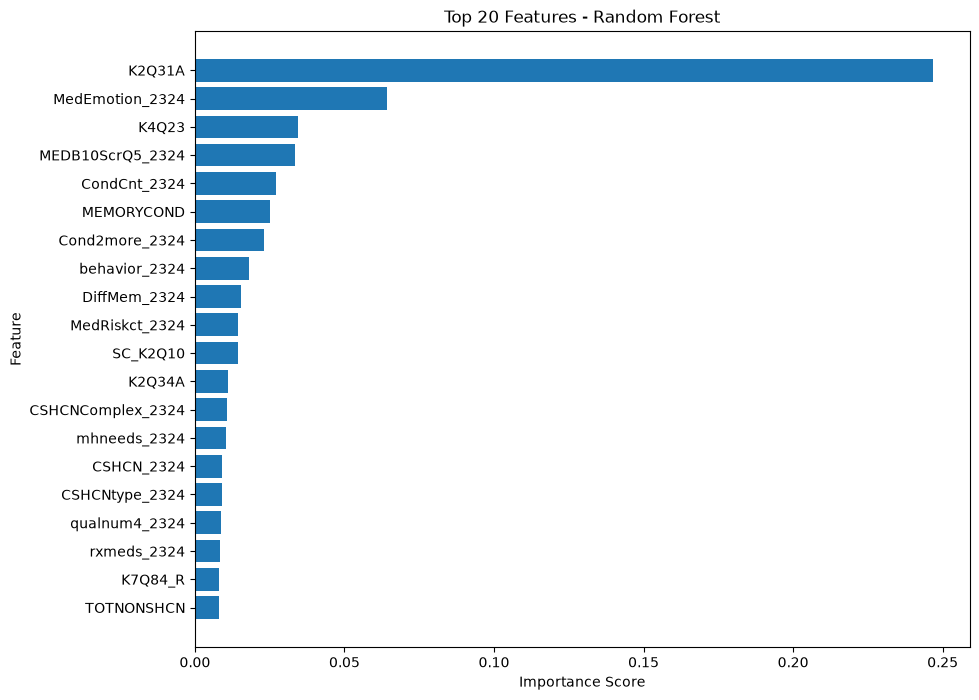

In [16]:
# =====================================================
# VISUALIZE TOP 20 RANDOM FOREST FEATURES
# =====================================================

import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Features - Random Forest")

plt.show()

In [17]:
# =====================================================
# REMOVE ADHD LEAKAGE VARIABLES ONLY
# =====================================================

leakage_cols = [
    "K2Q31A",
    "K2Q31B",
    "K2Q31C",
    "K2Q31D"
]

X = X.drop(columns=leakage_cols, errors="ignore")

print("Remaining Features:", X.shape[1])

Remaining Features: 579


In [18]:
rf.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [19]:
# =====================================================
# EXTRACT FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                  Feature  Importance
395       MedEmotion_2324    0.065593
396      MEDB10ScrQ5_2324    0.049090
78                  K4Q23    0.047535
34             MEMORYCOND    0.035698
313          CondCnt_2324    0.027042
551        MedRiskct_2324    0.023268
365          DiffMem_2324    0.022126
314        Cond2more_2324    0.021892
379  CSHCNComplexExp_2324    0.016033
354         BehavSev_2324    0.015269
332         behavior_2324    0.013577
54                 K2Q34A    0.013495
368            CSHCN_2324    0.012018
369           rxmeds_2324    0.011611
377          mhneeds_2324    0.010682
373          mhealth_2324    0.010411
374         qualnum4_2324    0.009433
552     MedRisk2more_2324    0.009074
235              SC_K2Q22    0.008134
231              SC_K2Q10    0.007883


In [20]:
# =====================================================
# SAVE CLEAN RANDOM FOREST RESULTS
# =====================================================

top30_rf = importance_df.head(30)

top30_rf.to_csv(
    "../data/FEATURE_SELECTION/Top30_RF_Features_Clean.csv",
    index=False
)

print("Clean RF Results Saved")

Clean RF Results Saved


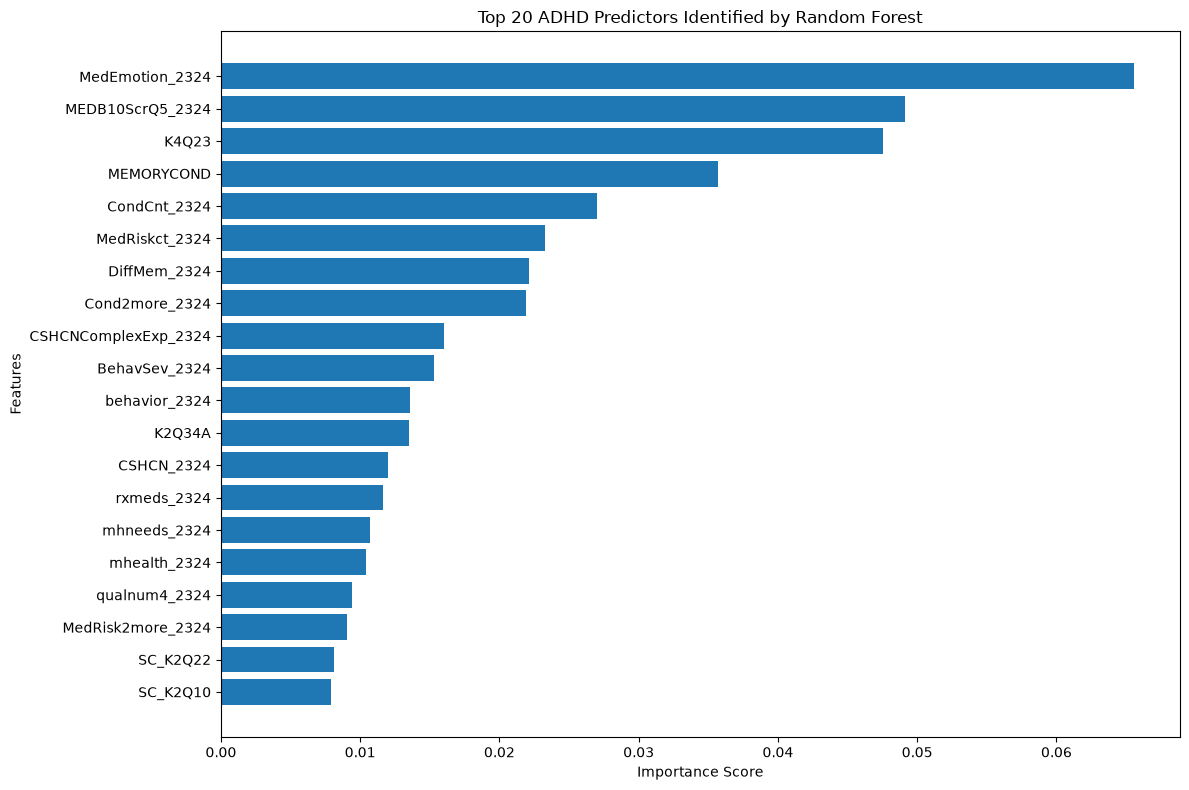

In [23]:
plt.figure(figsize=(12,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 ADHD Predictors Identified by Random Forest")

plt.tight_layout()

# SAVE FIRST
plt.savefig(
    "../data/FEATURE_SELECTION/RF_Top20_Features.png",
    dpi=300,
    bbox_inches="tight"
)

# THEN SHOW
plt.show()

# Random Forest Feature Selection

## Objective
Identify the most important predictors of ADHD using Random Forest feature importance.

## Results
After removing target leakage variables, MedEmotion_2324, MEDB10ScrQ5_2324, K4Q23, MEMORYCOND, and CondCnt_2324 emerged as the most influential predictors.

## Conclusion
Random Forest suggests that emotional health, memory-related conditions, behavioral characteristics, and overall medical burden are strongly associated with ADHD status.

In [22]:
plt.savefig(
    "../data/FEATURE_SELECTION/RF_Top20_Features.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [24]:
importance_df.to_csv(
    "../data/FEATURE_SELECTION/RF_All_Features.csv",
    index=False
)

In [25]:
# =====================================================
# SECTION 4: MUTUAL INFORMATION FEATURE SELECTION
# =====================================================
# Mutual Information measures how much information
# each feature provides about ADHD status.
# =====================================================

In [26]:
# =====================================================
# COMPUTE MUTUAL INFORMATION SCORES
# =====================================================

from sklearn.feature_selection import mutual_info_classif

print("Calculating Mutual Information Scores...")

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

print("Calculation Complete!")

Calculating Mutual Information Scores...
Calculation Complete!


In [27]:
# =====================================================
# CREATE MUTUAL INFORMATION TABLE
# =====================================================

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI_Score": mi_scores
})

mi_df = mi_df.sort_values(
    by="MI_Score",
    ascending=False
)

print(mi_df.head(20))

                  Feature  MI_Score
396      MEDB10ScrQ5_2324  0.199993
313          CondCnt_2324  0.162144
395       MedEmotion_2324  0.158796
314        Cond2more_2324  0.151263
78                  K4Q23  0.137271
377          mhneeds_2324  0.125867
551        MedRiskct_2324  0.122259
552     MedRisk2more_2324  0.121020
379  CSHCNComplexExp_2324  0.116763
368            CSHCN_2324  0.116365
227              SC_CSHCN  0.114412
378    CSHCNExpanded_2324  0.113231
376     CSHCNComplex_2324  0.113208
374         qualnum4_2324  0.110960
365          DiffMem_2324  0.109682
375        CSHCNtype_2324  0.109628
34             MEMORYCOND  0.108763
553     MedRisk1more_2324  0.104141
373          mhealth_2324  0.094501
369           rxmeds_2324  0.094419


In [28]:
# =====================================================
# SAVE ALL MUTUAL INFORMATION SCORES
# =====================================================

mi_df.to_csv(
    "../data/FEATURE_SELECTION/MI_All_Features.csv",
    index=False
)

print("MI_All_Features.csv Saved")

MI_All_Features.csv Saved


In [29]:
# =====================================================
# SAVE TOP 30 FEATURES
# =====================================================

top30_mi = mi_df.head(30)

top30_mi.to_csv(
    "../data/FEATURE_SELECTION/Top30_MI_Features.csv",
    index=False
)

print("Top30_MI_Features.csv Saved")

Top30_MI_Features.csv Saved


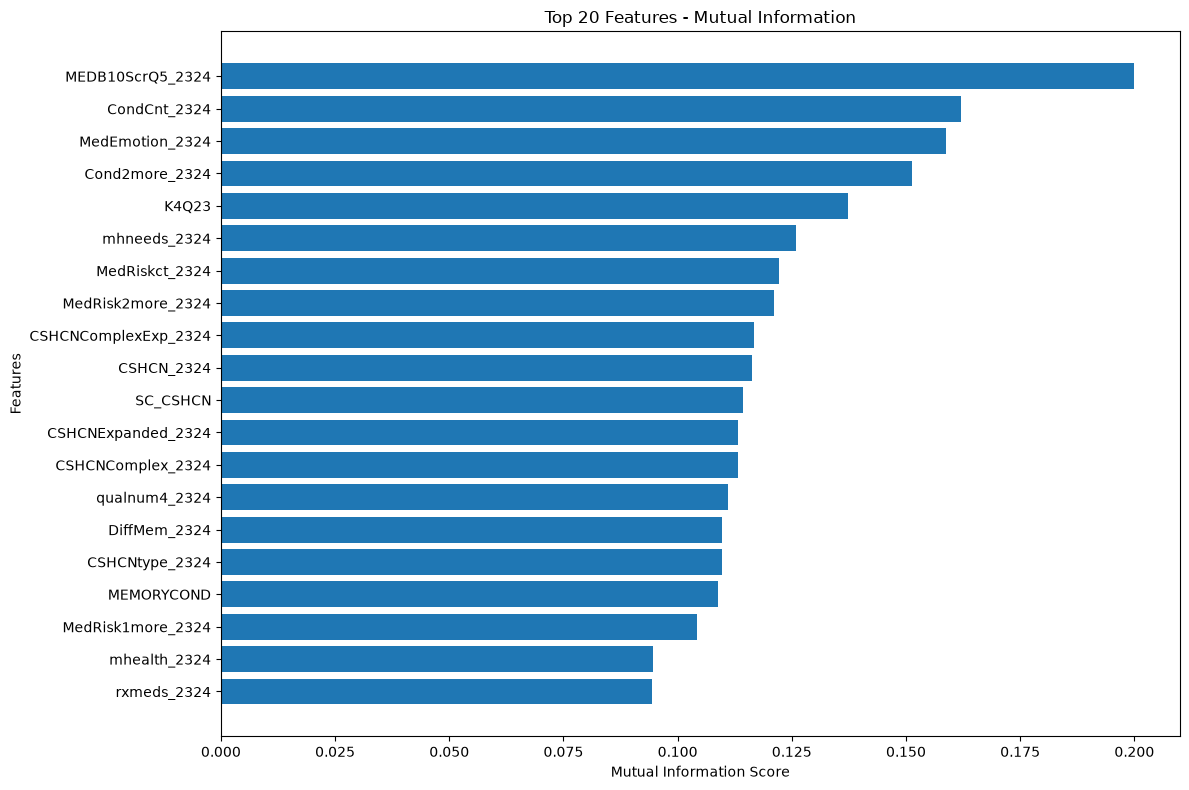

In [30]:
# =====================================================
# VISUALIZE TOP 20 MI FEATURES
# =====================================================

import matplotlib.pyplot as plt

top20_mi = mi_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20_mi["Feature"],
    top20_mi["MI_Score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Top 20 Features - Mutual Information")

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/MI_Top20_Features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Mutual Information Feature Selection

## Objective
Identify ADHD-related features using Mutual Information.

## Method
Mutual Information measures the amount of information a feature provides about ADHD status without relying on a specific machine learning model.

## Output Files
- MI_All_Features.csv
- Top30_MI_Features.csv
- MI_Top20_Features.png

In [31]:
# =====================================================
# SECTION 5: XGBOOST FEATURE SELECTION
# =====================================================
# XGBoost ranks features based on their contribution
# to improving prediction performance.
# =====================================================

from xgboost import XGBClassifier

In [32]:
# =====================================================
# TRAIN XGBOOST MODEL
# =====================================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(X, y)

print("Training Complete!")

Training XGBoost...
Training Complete!


In [33]:
# =====================================================
# EXTRACT XGBOOST FEATURE IMPORTANCE
# =====================================================

xgb_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance_df = xgb_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance_df.head(20))

                Feature  Importance
396    MEDB10ScrQ5_2324    0.318386
395     MedEmotion_2324    0.201955
48               K2Q33A    0.024646
34           MEMORYCOND    0.022757
466     SchlEngage_2324    0.017696
376   CSHCNComplex_2324    0.015942
49               K2Q32A    0.014584
161             K7Q84_R    0.012540
164             K7Q83_R    0.012457
378  CSHCNExpanded_2324    0.009028
335         speech_2324    0.007895
9                SC_SEX    0.007617
230          SC_ENGLISH    0.006397
234            SC_K2Q19    0.006038
360      Diff2more_2324    0.005977
353      DepresSev_2324    0.005526
330        anxiety_2324    0.005401
373        mhealth_2324    0.005338
235            SC_K2Q22    0.005024
331        depress_2324    0.004917


In [34]:
# =====================================================
# SAVE ALL XGBOOST FEATURES
# =====================================================

xgb_importance_df.to_csv(
    "../data/FEATURE_SELECTION/XGB_All_Features.csv",
    index=False
)

print("XGB_All_Features.csv Saved")

XGB_All_Features.csv Saved


In [35]:
# =====================================================
# SAVE TOP 30 FEATURES
# =====================================================

top30_xgb = xgb_importance_df.head(30)

top30_xgb.to_csv(
    "../data/FEATURE_SELECTION/Top30_XGB_Features.csv",
    index=False
)

print("Top30_XGB_Features.csv Saved")

Top30_XGB_Features.csv Saved


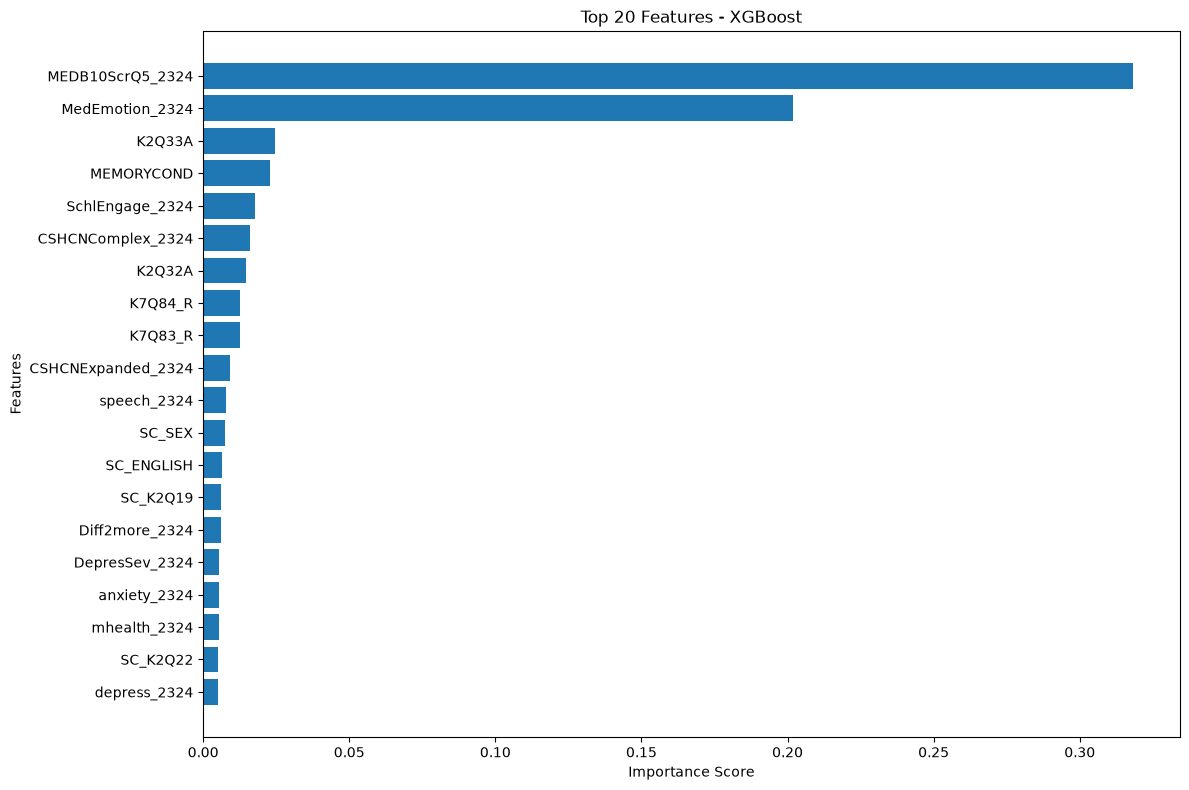

In [36]:
# =====================================================
# VISUALIZE TOP 20 XGBOOST FEATURES
# =====================================================

import matplotlib.pyplot as plt

top20_xgb = xgb_importance_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20_xgb["Feature"],
    top20_xgb["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Features - XGBoost")

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/XGB_Top20_Features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# XGBoost Feature Selection

## Objective
Identify ADHD-related features using XGBoost feature importance.

## Method
XGBoost is a gradient boosting algorithm that ranks features according to their contribution to improving predictive performance.

## Output Files
- XGB_All_Features.csv
- Top30_XGB_Features.csv
- XGB_Top20_Features.png

In [37]:
print(X.min().min())

0.0


In [38]:
# =====================================================
# SECTION 6: CHI-SQUARE FEATURE SELECTION
# =====================================================
# Chi-Square measures statistical association
# between features and ADHD status.
# =====================================================

from sklearn.feature_selection import chi2

In [39]:
# =====================================================
# COMPUTE CHI-SQUARE SCORES
# =====================================================

print("Calculating Chi-Square Scores...")

chi_scores, p_values = chi2(X, y)

print("Calculation Complete!")

Calculating Chi-Square Scores...
Calculation Complete!


In [40]:
# =====================================================
# CREATE CHI-SQUARE TABLE
# =====================================================

chi_df = pd.DataFrame({
    "Feature": X.columns,
    "Chi2_Score": chi_scores,
    "P_Value": p_values
})

chi_df = chi_df.sort_values(
    by="Chi2_Score",
    ascending=False
)

print(chi_df.head(20))

                  Feature    Chi2_Score  P_Value
3                    HHID  1.344093e+06      0.0
274              fwc_2324  1.579660e+05      0.0
573  nomObesity6to17_2324  1.477461e+05      0.0
24                 A2_AGE  1.155785e+05      0.0
313          CondCnt_2324  7.623746e+04      0.0
374         qualnum4_2324  5.036060e+04      0.0
375        CSHCNtype_2324  4.246890e+04      0.0
551        MedRiskct_2324  3.758092e+04      0.0
465          SpEdAge_2324  2.639655e+04      0.0
431         SpSerAge_2324  1.605511e+04      0.0
225              TOTCSHCN  1.404474e+04      0.0
380         DailyAct_2324  1.364556e+04      0.0
561        RiskCombo_2324  1.167274e+04      0.0
360        Diff2more_2324  1.108566e+04      0.0
379  CSHCNComplexExp_2324  1.042758e+04      0.0
560      WCRIdomains_2324  9.552446e+03      0.0
314        Cond2more_2324  9.348557e+03      0.0
552     MedRisk2more_2324  9.083575e+03      0.0
500            ACEct_2324  8.863338e+03      0.0
376     CSHCNComplex

In [41]:
# Check if HHID exists
print(df["HHID"].head())

# Check uniqueness
print("Unique HHID:", df["HHID"].nunique())
print("Rows:", len(df))

0    23000001
1    23000025
2    23000027
3    23000030
4    23000033
Name: HHID, dtype: int64
Unique HHID: 89228
Rows: 89228


In [42]:
X = X.drop(columns=["HHID"], errors="ignore")

In [43]:
X = X.drop(
    columns=["fwc_2324"],
    errors="ignore"
)

print(X.shape)

(89228, 577)


In [44]:
from sklearn.feature_selection import chi2

chi_scores, p_values = chi2(X, y)

chi_df = pd.DataFrame({
    "Feature": X.columns,
    "Chi2_Score": chi_scores,
    "P_Value": p_values
})

chi_df = chi_df.sort_values(
    by="Chi2_Score",
    ascending=False
)

print(chi_df.head(20))

                  Feature     Chi2_Score  P_Value
571  nomObesity6to17_2324  147746.102028      0.0
23                 A2_AGE  115578.542126      0.0
311          CondCnt_2324   76237.464292      0.0
372         qualnum4_2324   50360.601279      0.0
373        CSHCNtype_2324   42468.899728      0.0
549        MedRiskct_2324   37580.923119      0.0
463          SpEdAge_2324   26396.547647      0.0
429         SpSerAge_2324   16055.113879      0.0
224              TOTCSHCN   14044.736614      0.0
378         DailyAct_2324   13645.557505      0.0
559        RiskCombo_2324   11672.739969      0.0
358        Diff2more_2324   11085.659189      0.0
377  CSHCNComplexExp_2324   10427.579063      0.0
558      WCRIdomains_2324    9552.446429      0.0
312        Cond2more_2324    9348.556762      0.0
550     MedRisk2more_2324    9083.574574      0.0
498            ACEct_2324    8863.337920      0.0
374     CSHCNComplex_2324    5641.428581      0.0
193             HCABILITY    5412.366831      0.0


In [45]:
chi_df.to_csv(
    "../data/FEATURE_SELECTION/CHI_All_Features.csv",
    index=False
)

print("CHI_All_Features.csv Saved")

CHI_All_Features.csv Saved


In [46]:
top30_chi = chi_df.head(30)

top30_chi.to_csv(
    "../data/FEATURE_SELECTION/Top30_CHI_Features.csv",
    index=False
)

print("Top30_CHI_Features.csv Saved")

Top30_CHI_Features.csv Saved


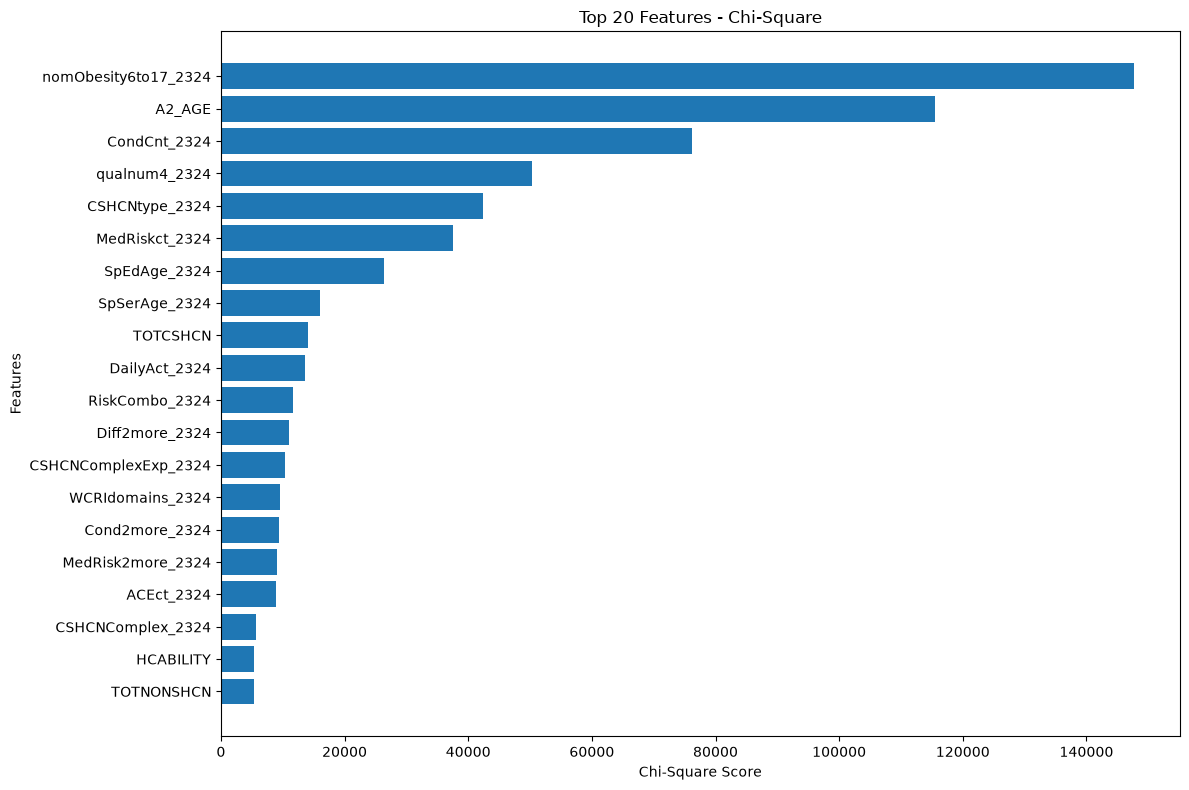

In [47]:
import matplotlib.pyplot as plt

top20_chi = chi_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20_chi["Feature"],
    top20_chi["Chi2_Score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Chi-Square Score")
plt.ylabel("Features")
plt.title("Top 20 Features - Chi-Square")

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/CHI_Top20_Features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Chi-Square Feature Selection

## Objective
Identify statistically significant features associated with ADHD.

## Method
Chi-Square evaluates the strength of association between each feature and ADHD status.

## Output Files
- CHI_All_Features.csv
- Top30_CHI_Features.csv
- CHI_Top20_Features.png

# SECTION 7: Consensus Feature Analysis

Feature selection methods often identify different sets of important variables.

To obtain a robust set of ADHD predictors, we compare the Top 30 features selected by:

1. Random Forest
2. Mutual Information
3. XGBoost
4. Chi-Square

A consensus score is assigned to each feature based on the number of methods that selected it.

Features appearing in multiple methods are considered more reliable and informative for ADHD prediction.

In [48]:
# ============================================================
# LOAD TOP 30 FEATURES FROM ALL METHODS
# ============================================================

import pandas as pd

rf = pd.read_csv("Top30_RF_Features.csv")
mi = pd.read_csv("Top30_MI_Features.csv")
xgb = pd.read_csv("Top30_XGB_Features.csv")
chi = pd.read_csv("Top30_CHI_Features.csv")

print("RF Features :", rf.shape)
print("MI Features :", mi.shape)
print("XGB Features:", xgb.shape)
print("CHI Features:", chi.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'Top30_RF_Features.csv'

In [49]:
# ============================================================
# LOAD TOP 30 FEATURES FROM ALL METHODS
# ============================================================

import pandas as pd

rf = pd.read_csv("data/FEATURE_SELECTION/Top30_RF_Features.csv")
mi = pd.read_csv("data/FEATURE_SELECTION/Top30_MI_Features.csv")
xgb = pd.read_csv("data/FEATURE_SELECTION/Top30_XGB_Features.csv")
chi = pd.read_csv("data/FEATURE_SELECTION/Top30_CHI_Features.csv")

print("RF Features :", rf.shape)
print("MI Features :", mi.shape)
print("XGB Features:", xgb.shape)
print("CHI Features:", chi.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/FEATURE_SELECTION/Top30_RF_Features.csv'

In [50]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFolders in current location:")
print(os.listdir())

Current Working Directory:
c:\Users\91960\Desktop\ADHD_Explainability_Project\notebooks

Folders in current location:
['01_Preprocessing.ipynb', '02_Light_Borderline_SMOTE.ipynb', '03_XGBoost.ipynb', '04_SHAP.ipynb', '05_NSCH_Preprocessing.ipynb', '06_Feature_Selection_Comparison.ipynb']


In [51]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "Top30_RF_Features.csv" in file:
            print(os.path.join(root, file))

In [52]:
# ============================================================
# LOAD TOP 30 FEATURES FROM ALL METHODS
# ============================================================

import pandas as pd

rf = pd.read_csv("../data/FEATURE_SELECTION/Top30_RF_Features.csv")
mi = pd.read_csv("../data/FEATURE_SELECTION/Top30_MI_Features.csv")
xgb = pd.read_csv("../data/FEATURE_SELECTION/Top30_XGB_Features.csv")
chi = pd.read_csv("../data/FEATURE_SELECTION/Top30_CHI_Features.csv")

print("RF Features :", rf.shape)
print("MI Features :", mi.shape)
print("XGB Features:", xgb.shape)
print("CHI Features:", chi.shape)

RF Features : (30, 2)
MI Features : (30, 2)
XGB Features: (30, 2)
CHI Features: (30, 3)


# SECTION 7: Consensus Feature Analysis

Different feature selection techniques often identify different sets of important variables.

To improve robustness and reliability, we compare the Top 30 features selected by:

- Random Forest
- Mutual Information
- XGBoost
- Chi-Square

A consensus score is calculated for each feature based on the number of methods that selected it.

Features selected by multiple methods are considered stronger predictors of ADHD and will be prioritized in subsequent analysis.

In [53]:
# ============================================================
# CHECK COLUMN NAMES
# ============================================================

print("RF Columns :", rf.columns.tolist())
print("MI Columns :", mi.columns.tolist())
print("XGB Columns:", xgb.columns.tolist())
print("CHI Columns:", chi.columns.tolist())

RF Columns : ['Feature', 'Importance']
MI Columns : ['Feature', 'MI_Score']
XGB Columns: ['Feature', 'Importance']
CHI Columns: ['Feature', 'Chi2_Score', 'P_Value']


## Converting Feature Lists into Sets

To compare features selected by different feature selection methods, the Top 30 feature lists are converted into Python sets.

Using sets allows efficient identification of common features across methods and supports the calculation of consensus scores.

In [54]:
# ============================================================
# CONVERT TOP 30 FEATURES INTO SETS
# ============================================================

rf_set = set(rf["Feature"])
mi_set = set(mi["Feature"])
xgb_set = set(xgb["Feature"])
chi_set = set(chi["Feature"])

print("RF Features :", len(rf_set))
print("MI Features :", len(mi_set))
print("XGB Features:", len(xgb_set))
print("CHI Features:", len(chi_set))

RF Features : 30
MI Features : 30
XGB Features: 30
CHI Features: 30


## Creating the Master Feature List

A master list of unique features is created by combining the Top 30 features from all four feature selection methods.

This list represents all candidate ADHD predictors identified during feature selection.

In [55]:
# ============================================================
# CREATE MASTER FEATURE LIST
# ============================================================

all_features = rf_set | mi_set | xgb_set | chi_set

print("Total Unique Features:", len(all_features))

Total Unique Features: 66


## Consensus Score Calculation

For each feature, a consensus score is calculated.

The score represents the number of feature selection methods that identified the feature as important.

Consensus Score Interpretation:

- 4 → Selected by all four methods
- 3 → Selected by three methods
- 2 → Selected by two methods
- 1 → Selected by only one method

Higher scores indicate stronger agreement among feature selection techniques.

In [56]:
# ============================================================
# CALCULATE CONSENSUS SCORES
# ============================================================

consensus = []

for feature in all_features:

    count = (
        (feature in rf_set) +
        (feature in mi_set) +
        (feature in xgb_set) +
        (feature in chi_set)
    )

    consensus.append([feature, count])

print("Consensus score calculation completed.")

Consensus score calculation completed.


In [57]:
# ============================================================
# CREATE CONSENSUS DATAFRAME
# ============================================================

consensus_df = pd.DataFrame(
    consensus,
    columns=["Feature", "Methods_Selected"]
)

consensus_df = consensus_df.sort_values(
    by="Methods_Selected",
    ascending=False
)

consensus_df.head(20)

,Feature,Methods_Selected
41,behavior_2324,4
48,CondCnt_2324,4
52,MedEmotion_2324,3
56,mhneeds_2324,3
3,SC_K2Q22,3
4,K2Q34A,3
17,MedRiskct_2324,3
12,mhealth_2324,3
7,CSHCNtype_2324,3
6,MEDB10ScrQ5_2324,3


In [58]:
consensus_df["Methods_Selected"].value_counts()

Methods_Selected
1    31
2    18
3    15
4     2
Name: count, dtype: int64

## Saving Consensus Feature Scores

The consensus scores are saved for future reference and model development.

This file provides a summary of how frequently each feature was selected across the four feature selection methods.

In [59]:
# ============================================================
# SAVE CONSENSUS FEATURE SCORES
# ============================================================

consensus_df.to_csv(
    "../data/FEATURE_SELECTION/Consensus_Features.csv",
    index=False
)

print("Consensus features saved successfully.")

Consensus features saved successfully.


## Identifying Strong Consensus Features

Features selected by at least three different feature selection methods are considered strong predictors.

These variables demonstrate consistent importance across multiple analytical approaches and are retained for further modeling and explainability analysis.

In [60]:
# ============================================================
# FEATURES SELECTED BY 3 OR MORE METHODS
# ============================================================

top_consensus = consensus_df[
    consensus_df["Methods_Selected"] >= 3
]

print("Number of Consensus Features:", len(top_consensus))

top_consensus

Number of Consensus Features: 17


,Feature,Methods_Selected
41,behavior_2324,4
48,CondCnt_2324,4
52,MedEmotion_2324,3
56,mhneeds_2324,3
3,SC_K2Q22,3
4,K2Q34A,3
17,MedRiskct_2324,3
12,mhealth_2324,3
7,CSHCNtype_2324,3
6,MEDB10ScrQ5_2324,3


In [61]:
# ============================================================
# SAVE FINAL CONSENSUS FEATURES
# ============================================================

top_consensus.to_csv(
    "../data/FEATURE_SELECTION/Final_Consensus_Features.csv",
    index=False
)

print("Final consensus features saved successfully.")

Final consensus features saved successfully.


## Visualizing Consensus Scores

The following chart illustrates the level of agreement among feature selection methods.

Features with higher consensus scores were consistently identified as important predictors of ADHD and therefore provide stronger evidence of relevance.

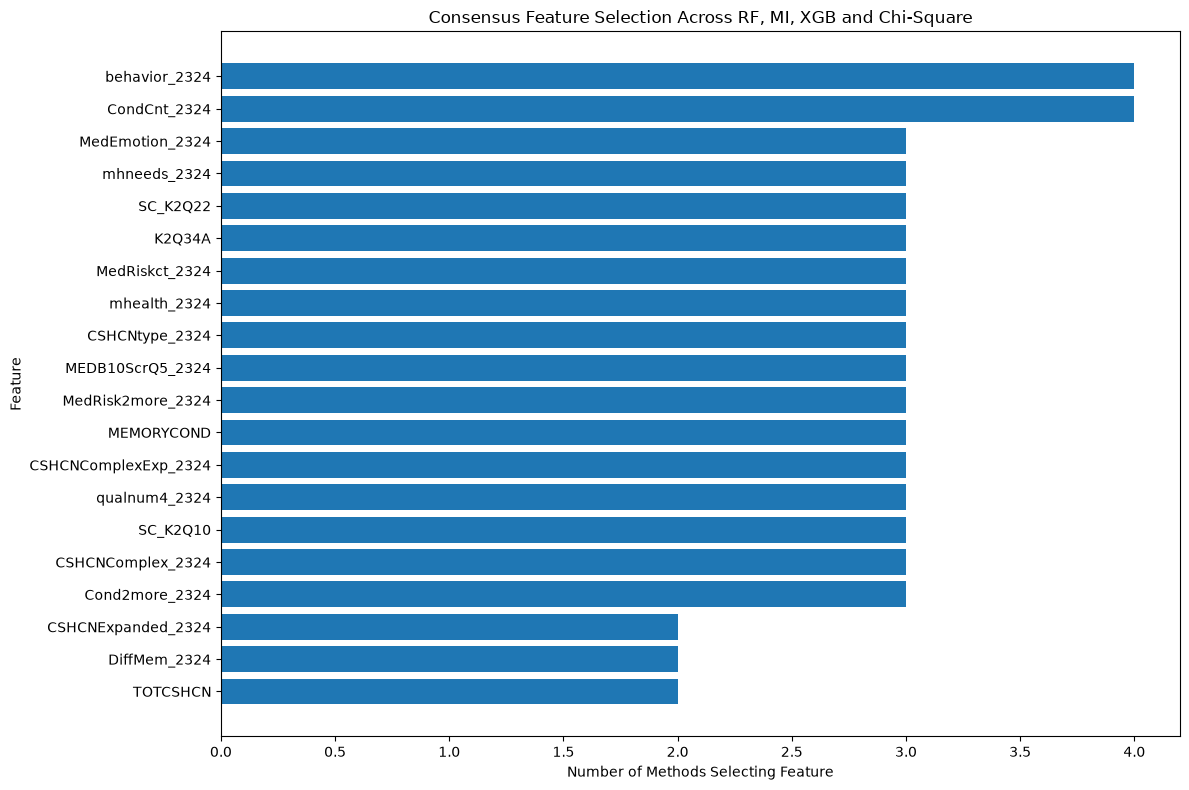

In [62]:
# ============================================================
# VISUALIZE CONSENSUS FEATURES
# ============================================================

import matplotlib.pyplot as plt

top_features = consensus_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top_features["Feature"],
    top_features["Methods_Selected"]
)

plt.xlabel("Number of Methods Selecting Feature")
plt.ylabel("Feature")

plt.title(
    "Consensus Feature Selection Across RF, MI, XGB and Chi-Square"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

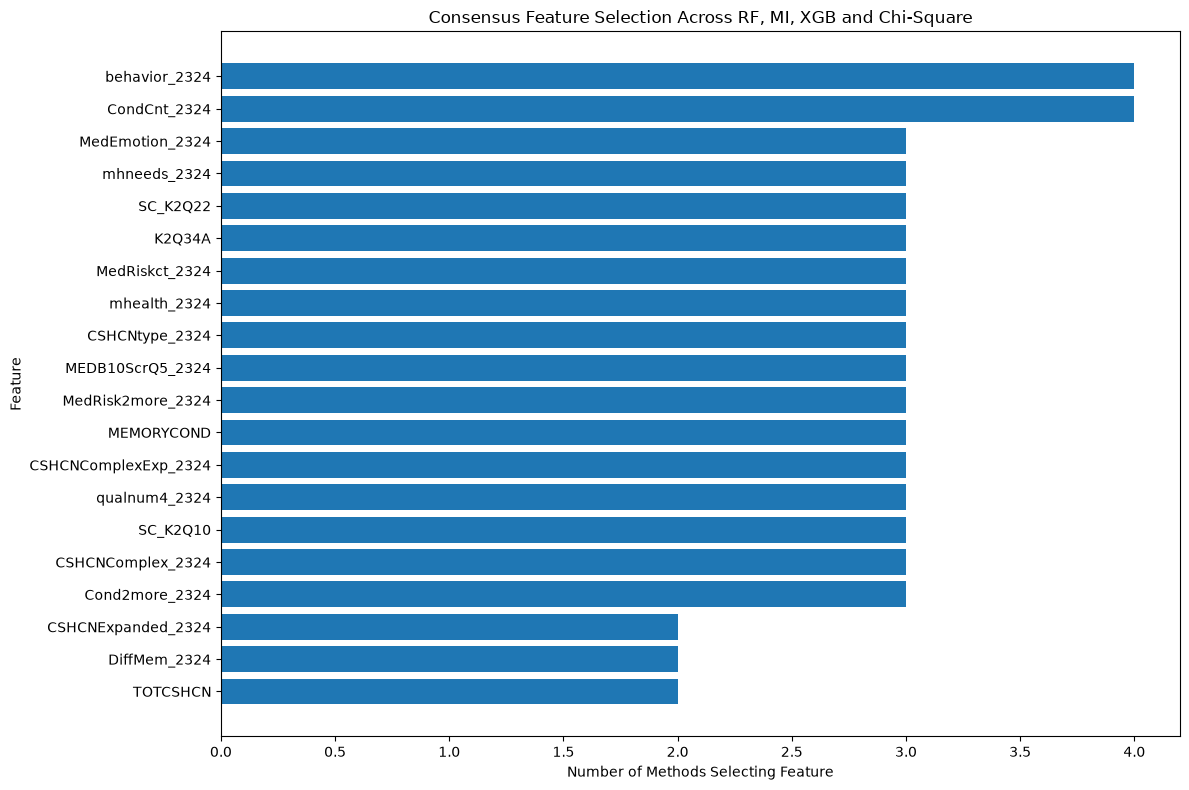

Consensus plot saved successfully.


In [63]:
# ============================================================
# SAVE CONSENSUS PLOT
# ============================================================

plt.figure(figsize=(12,8))

plt.barh(
    top_features["Feature"],
    top_features["Methods_Selected"]
)

plt.xlabel("Number of Methods Selecting Feature")
plt.ylabel("Feature")

plt.title(
    "Consensus Feature Selection Across RF, MI, XGB and Chi-Square"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../data/FEATURE_SELECTION/Consensus_Top20_Features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Consensus plot saved successfully.")

## Conclusion

Consensus feature analysis was performed by comparing the Top 30 features selected by Random Forest, Mutual Information, XGBoost, and Chi-Square methods.

A total of 66 unique features were identified across all methods.

Among them:

- 2 features were selected by all four methods.
- 15 features were selected by three methods.
- 17 features were selected by at least three methods.

These consensus features represent the most robust predictors of ADHD and will be used in subsequent explainability analysis and model interpretation.

In [64]:
top_consensus[["Feature", "Methods_Selected"]]

,Feature,Methods_Selected
41,behavior_2324,4
48,CondCnt_2324,4
52,MedEmotion_2324,3
56,mhneeds_2324,3
3,SC_K2Q22,3
4,K2Q34A,3
17,MedRiskct_2324,3
12,mhealth_2324,3
7,CSHCNtype_2324,3
6,MEDB10ScrQ5_2324,3
